In [2]:
# Imports & Global Configuration 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

# Style
sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.15)
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CROP_NAMES = {
    "cereal_legume": "Cereals & Legumes",
    "sugar_beet": "Sugar Beet",
    "sunflower": "Sunflower",
    "potato": "Potato",
    "vegetable": "Vegetables",
    "fruit_berry": "Fruits & Berries",
}
# Color palette for the 6 crops (consistent throughout)
CROP_COLORS = {
    "cereal_legume": "#E69F00",
    "sugar_beet": "#56B4E9",
    "sunflower": "#F0E442",
    "potato": "#009E73",
    "vegetable": "#D55E00",
    "fruit_berry": "#CC79A7",
}

print("✅ Libraries loaded. Ready to go!")

✅ Libraries loaded. Ready to go!


In [3]:
# Load & Preview Data
df = pd.read_csv("crop-growing.csv")
print(f"Shape: {df.shape[0]} rows * {df.shape[1]} columns")
print(f"Time Span: {df['year'].min()} - {df['year'].max()}\n")
df.head(10)

Shape: 33 rows * 13 columns
Time Span: 1991 - 2023



,year,cereal_legume_ths_ha,sugar_beet_ths_ha,sunflower_ths_ha,potato_ths_ha,vegetable_ths_ha,fruit_berry_ths_ha,cereal_legume_ths_tons,sugar_beet_ths_tons,sunflower_ths_tons,potato_ths_tons,vegetable_ths_tons,fruit_berry_ths_tons
0,1991,14671,1558,1601,1533,477,842,38674,36168,2311,14550,5932,1537
1,1992,13903,1498,1641,1702,500,834,38537,28783,2127,20277,5310,2122
2,1993,14305,1530,1637,1552,474,818,45623,33717,2075,21009,6055,2798
3,1994,13527,1485,1784,1532,461,804,35497,28138,1569,16102,5142,1153
4,1995,14152,1475,2020,1532,507,794,33930,29650,2860,14729,5880,1897
5,1996,13248,1359,2107,1547,479,772,24571,23009,2123,18410,5070,1924
6,1997,15051,1104,2065,1579,483,752,35472,17663,2308,16701,5168,2793
7,1998,13718,1017,2531,1513,461,468,26471,15523,2266,15405,5492,1178
8,1999,13154,1022,2889,1552,499,450,24581,14064,2794,12723,5324,766
9,2000,13646,856,2943,1629,541,425,24459,13199,3457,19838,5821,1453


In [4]:
print("One\nTwo\nThree")

One
Two
Three


In [5]:
# Data Quality Audit
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

print("\n Column Data Types:")
print(df.dtypes.to_string())

print(f"\n Missing values: {df.isnull().sum().sum()} total")
print(f" Duplicate Rows: {df.duplicated().sum()}")
print(f" Year continuity: {df['year'].min()} - {df['year'].max()},"
      f" expected {df['year'].max() - df['year'].min() + 1} rows, "
      f" got {len(df)}")

# Check for any zero or negative values (anomalies)
numeric_cols = df.select_dtypes(include="number").columns.drop("year")
neg_or_zero = (df[numeric_cols] <= 0).sum()

if neg_or_zero.sum() > 0:
    print(f"\n Zero or negative values found:\n{neg_or_zero[neg_or_zero > 0]}")

else:
    print("\n No zero or negative values — all entries are positive")
    print("\n Data quality: CLEAN — no imputation or cleaning needed")
    

DATA QUALITY REPORT

 Column Data Types:
year                      int64
cereal_legume_ths_ha      int64
sugar_beet_ths_ha         int64
sunflower_ths_ha          int64
potato_ths_ha             int64
vegetable_ths_ha          int64
fruit_berry_ths_ha        int64
cereal_legume_ths_tons    int64
sugar_beet_ths_tons       int64
sunflower_ths_tons        int64
potato_ths_tons           int64
vegetable_ths_tons        int64
fruit_berry_ths_tons      int64

 Missing values: 0 total
 Duplicate Rows: 0
 Year continuity: 1991 - 2023, expected 33 rows,  got 33

 No zero or negative values — all entries are positive

 Data quality: CLEAN — no imputation or cleaning needed


In [6]:
# Descriptive Statistics
desc = df.describe().T
desc["cv_%"] = (desc["std"] / desc["mean"] * 100).round(1)
desc["iqr"] = desc["75%"] - desc["25%"]
desc["range"] = desc["max"] - desc["min"]

# Pretty display
desc_display = desc[["count", "mean", "std", "cv_%", "min", "25%", "50%", "75%", "max", "iqr", "range"]]
desc_display = desc_display.round(1)
desc_display

,count,mean,std,cv_%,min,25%,50%,75%,max,iqr,range
year,33.0,2007.0,9.7,0.5,1991.0,1999.0,2007.0,2015.0,2023.0,16.0,32.0
cereal_legume_ths_ha,33.0,14551.0,1179.9,8.1,10985.0,13903.0,14801.0,15434.0,16210.0,1531.0,5225.0
sugar_beet_ths_ha,33.0,708.5,460.6,65.0,184.0,292.0,610.0,1017.0,1558.0,725.0,1374.0
sunflower_ths_ha,33.0,3987.5,1587.9,39.8,1601.0,2531.0,4001.0,5220.0,6622.0,2689.0,5021.0
potato_ths_ha,33.0,1450.4,127.5,8.8,1208.0,1325.0,1453.0,1552.0,1702.0,227.0,494.0
vegetable_ths_ha,33.0,468.8,30.2,6.4,378.0,454.0,467.0,483.0,541.0,29.0,163.0
fruit_berry_ths_ha,33.0,393.1,227.0,57.7,187.0,235.0,271.0,450.0,842.0,215.0,655.0
cereal_legume_ths_tons,33.0,46554.8,16585.0,35.6,20234.0,35472.0,41809.0,60126.0,86010.0,24654.0,65776.0
sugar_beet_ths_tons,33.0,17037.3,7024.5,41.2,9150.0,13199.0,14882.0,18439.0,36168.0,5240.0,27018.0
sunflower_ths_tons,33.0,6935.7,4703.6,67.8,1569.0,2794.0,5324.0,11181.0,16392.0,8387.0,14823.0


In [7]:
# Most / Least Variable Indicators
area_cols = [c for c in df.columns if c.endswith("_ths_ha")]
prod_cols = [c for c in df.columns if c.endswith("_ths_tons")]

cv_area = (df[area_cols].std() / df[area_cols].mean() * 100).sort_values(ascending=False)
cv_prod = (df[prod_cols].std() / df[prod_cols].mean() * 100).sort_values(ascending=False)

print("Coefficient of Variation (%) — AREA planted:")
for col, val in cv_area.items():
    crop = col.replace("_ths_ha", "")
    print(f" {CROP_NAMES.get(crop, crop):22s} {val:6.1f}%")

print("\nCoefficient of Variation (%) - PRODUCTION:")
for col, val in cv_prod.items():
    crop = col.replace("_ths_tons", "")
    print(f"{CROP_NAMES.get(crop, crop):22s}  {val:6.1f}%")

Coefficient of Variation (%) — AREA planted:
 Sugar Beet               65.0%
 Fruits & Berries         57.7%
 Sunflower                39.8%
 Potato                    8.8%
 Cereals & Legumes         8.1%
 Vegetables                6.4%

Coefficient of Variation (%) - PRODUCTION:
Sunflower                 67.8%
Sugar Beet                41.2%
Cereals & Legumes         35.6%
Fruits & Berries          26.4%
Vegetables                23.5%
Potato                    14.2%


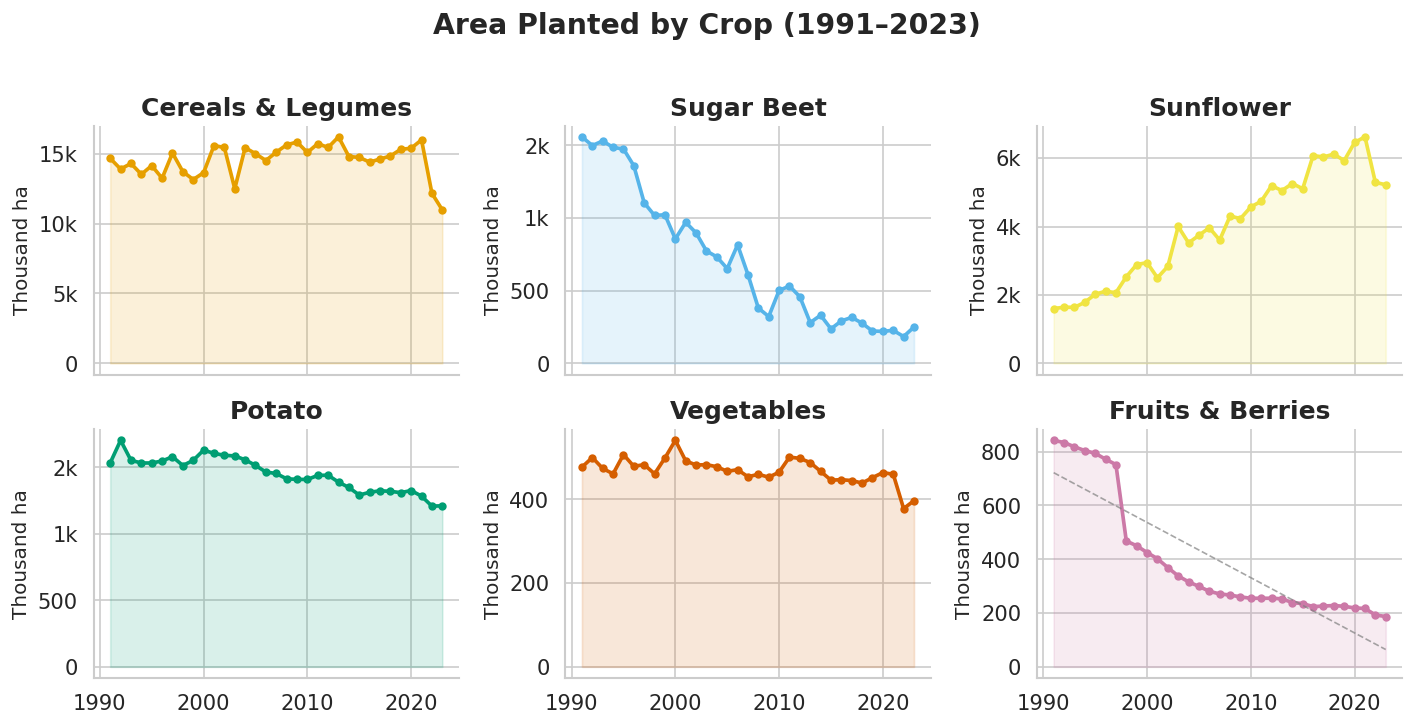

In [8]:
# Time-Series Trend Analysis
# Area Planted Over Time
fig, axes = plt.subplots(2,3, figsize=(12, 6), sharex=True)
axes = axes.flatten()

for i, col in enumerate(area_cols):
    crop = col.replace("_ths_ha", "")
    ax = axes[i]
    ax.plot(df['year'], df[col], color=CROP_COLORS[crop], linewidth=2.2, marker="o", markersize=4)
    ax.fill_between(df['year'], df[col], alpha=0.15, color=CROP_COLORS[crop])
    ax.set_title(CROP_NAMES[crop], fontweight="bold")
    ax.set_ylabel("Thousand ha")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000
else f"{x:.0f}"))

# Add trend line
z = np.polyfit(df["year"], df[col], 1)
ax.plot(df["year"], np.polyval(z, df["year"]), "--", color="gray", alpha=0.7, linewidth=1)


fig.suptitle("Area Planted by Crop (1991–2023)", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# FuncFormatter(my_function)
# my_function(x, pos)
# This is for  the (x,y) symbols

# lambda x is the same as:
# def format_label(x, pos):
    

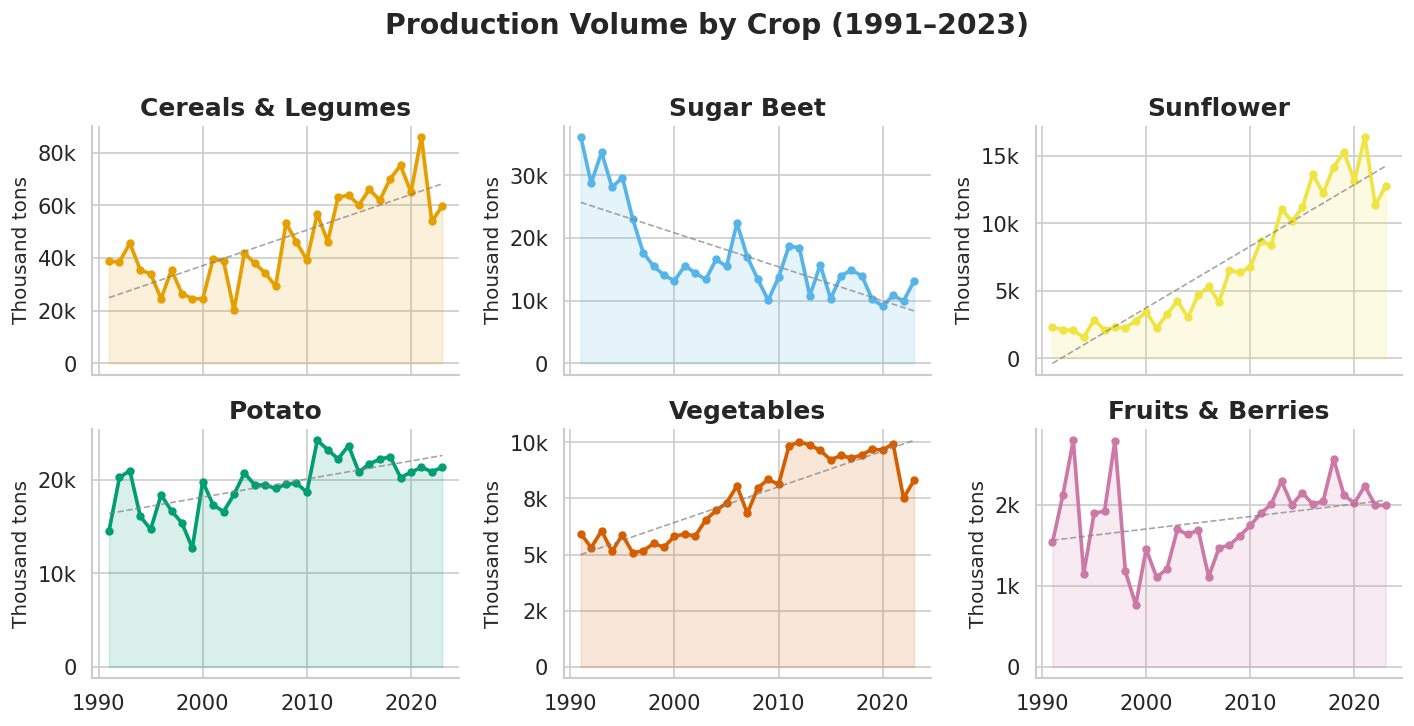

In [10]:
# Production Volume Over Time
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
axes = axes.flatten()

for i, col in enumerate(prod_cols):
    crop = col.replace("_ths_tons", "")
    ax = axes[i]
    ax.plot(df["year"], df[col], color=CROP_COLORS[crop], linewidth=2.2, marker="o", markersize=4)
    ax.fill_between(df["year"], df[col], alpha=0.15, color=CROP_COLORS[crop])
    ax.set_title(CROP_NAMES[crop], fontweight="bold")
    ax.set_ylabel("Thousand tons")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))
    
    # Add trend line
    z = np.polyfit(df["year"], df[col], 1)
    ax.plot(df["year"], np.polyval(z, df["year"]), "--", color="gray", alpha=0.7, linewidth=1)

fig.suptitle("Production Volume by Crop (1991–2023)", fontsize=17, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


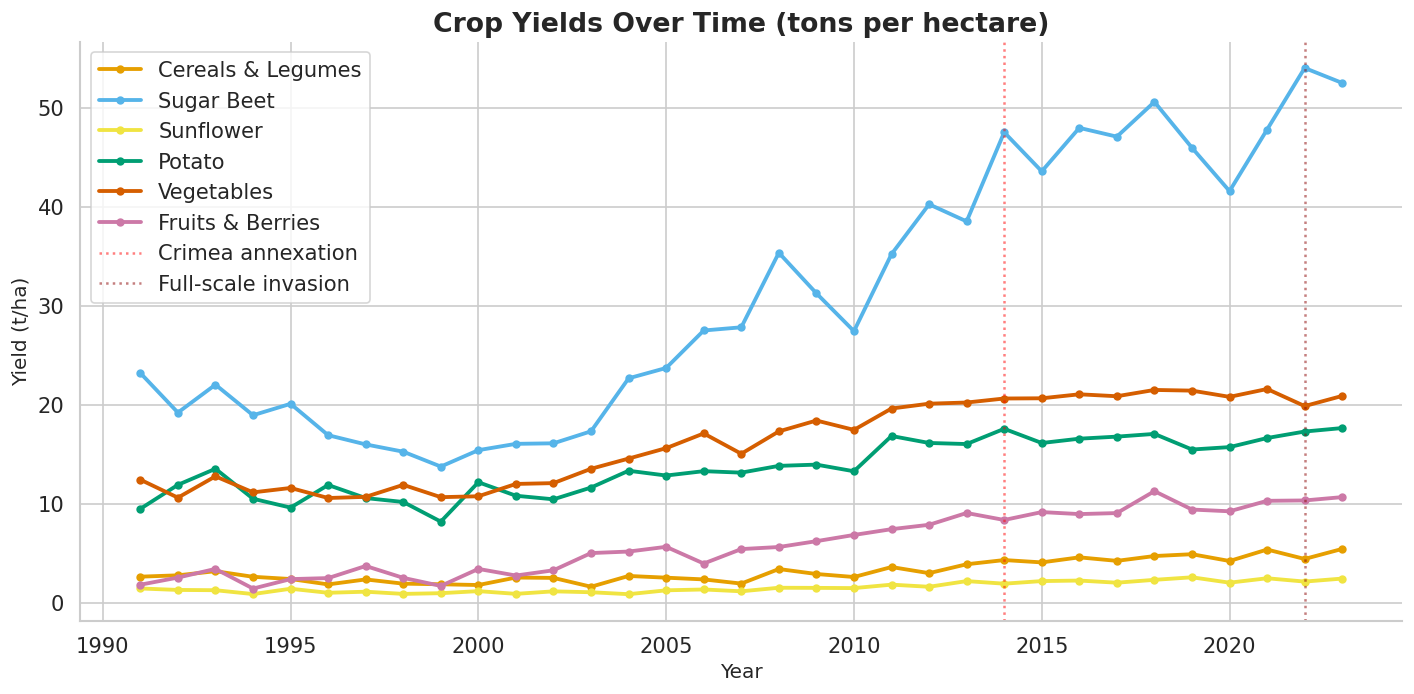

In [11]:
# Yield (Productivity) Analysis
# Compute Yields
crops = list(CROP_NAMES.keys())

for crop in crops:
    df[f"{crop}_yield_t_ha"] = (df[f"{crop}_ths_tons"] / df[f"{crop}_ths_ha"]).round(3)

yield_cols = [f"{c}_yield_t_ha" for c in crops]

# Plot yields
fig, ax = plt.subplots(figsize=(12, 6))

for crop in crops:
    col = f"{crop}_yield_t_ha"
    ax.plot(df["year"], df[col], label=CROP_NAMES[crop],
           color=CROP_COLORS[crop], linewidth=2.3, marker="o", markersize=4)
ax.set_title("Crop Yields Over Time (tons per hectare)", fontweight="bold", fontsize=16)
ax.set_xlabel("Year")
ax.set_ylabel("Yield (t/ha)")
ax.legend(loc="upper left", frameon=True, fontsize=11)
ax.axvline(2014, color="red", linestyle=":", alpha=0.5, label="Crimea annexation")
ax.axvline(2022, color="darkred", linestyle=":", alpha=0.5, label="Full-scale invasion")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Yield Summary Table 
yield_summary = pd.DataFrame({
    "Crop": [CROP_NAMES[c] for c in crops],
    "Avg Yield (t/ha)": [df[f"{c}_yield_t_ha"].mean() for c in crops],
    "Yield 1991": [df[f"{c}_yield_t_ha"].iloc[0] for c in crops],
    "Yield 2023": [df[f"{c}_yield_t_ha"].iloc[-1] for c in crops],
    "Yield Growth (×)": [round(df[f"{c}_yield_t_ha"].iloc[-1] / df[f"{c}_yield_t_ha"].iloc[0], 2) for c in crops],
    "Peak Yield": [df[f"{c}_yield_t_ha"].max() for c in crops],
    "Peak Year": [df.loc[df[f"{c}_yield_t_ha"].idxmax(), "year"] for c in crops],
}).round(2)

yield_summary.set_index("Crop")

,Avg Yield (t/ha),Yield 1991,Yield 2023,Yield Growth (×),Peak Yield,Peak Year
Crop,,,,,,
Cereals & Legumes,3.19,2.64,5.44,2.06,5.44,2023
Sugar Beet,30.88,23.21,52.52,2.26,54.03,2022
Sunflower,1.57,1.44,2.44,1.69,2.57,2019
Potato,13.66,9.49,17.65,1.86,17.65,2023
Vegetables,16.23,12.44,20.90,1.68,21.60,2021
Fruits & Berries,5.96,1.82,10.67,5.85,11.28,2018


In [13]:
# Structural Periods & Regime Analysis
# Define Historical Periods 
def assign_period(year):
    if year <= 1999:
        return "1991–1999 Transition"
    elif year <= 2013:
        return "2000–2013 Recovery"
    elif year <= 2021:
        return "2014–2021 EU Assoc."
    else:
        return "2022–2023 War"

df["period"] = df["year"].apply(assign_period)

# Aggregated comparison 
period_order = ["1991–1999 Transition", "2000–2013 Recovery", "2014–2021 EU Assoc.", "2022–2023 War"]

period_agg = df.groupby("period")[yield_cols + area_cols + prod_cols].mean()
period_agg = period_agg.reindex(period_order)

# Show yields by period
print("=" * 70)
print("AVERAGE YIELD (t/ha) BY HISTORICAL PERIOD")
print("=" * 70)
yield_period = period_agg[yield_cols].copy()
yield_period.columns = [CROP_NAMES[c] for c in crops]
yield_period.round(2)

AVERAGE YIELD (t/ha) BY HISTORICAL PERIOD


,Cereals & Legumes,Sugar Beet,Sunflower,Potato,Vegetables,Fruits & Berries
period,,,,,,
1991–1999 Transition,2.40,18.39,1.14,10.66,11.38,2.45
2000–2013 Recovery,2.67,26.77,1.36,13.42,15.99,5.56
2014–2021 EU Assoc.,4.56,46.52,2.22,16.50,21.07,9.47
2022–2023 War,4.93,53.28,2.29,17.48,20.39,10.51


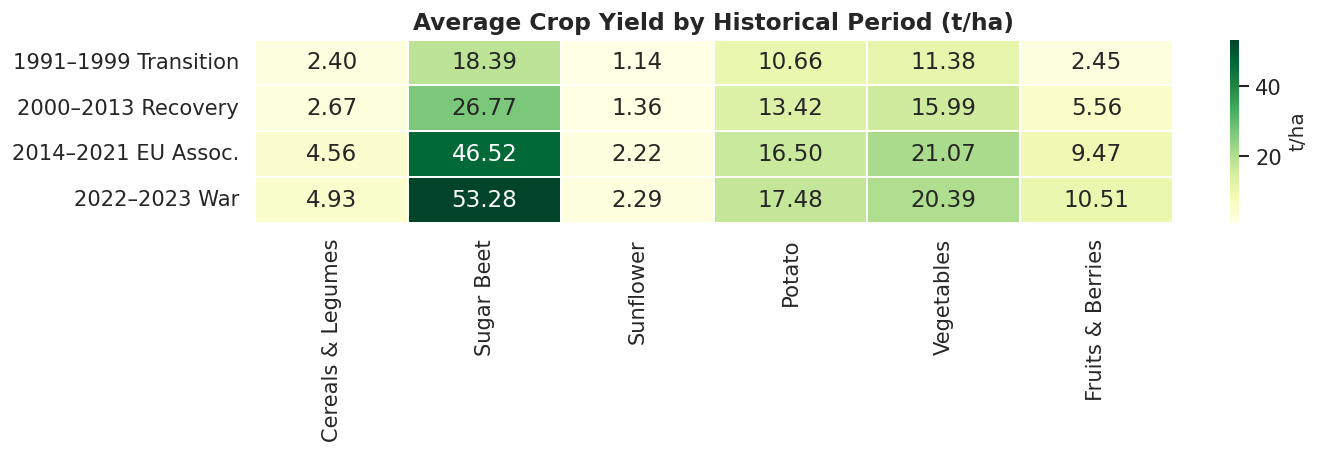

In [14]:
# Heatmap: yields by period 
fig, ax = plt.subplots(figsize=(12,4))

sns.heatmap(yield_period.round(2), annot=True, fmt=".2f", cmap="YlGn", linewidths=1, linecolor="white", cbar_kws={"label" : "t/ha"}, ax=ax)
ax.set_title("Average Crop Yield by Historical Period (t/ha)", fontweight="bold", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

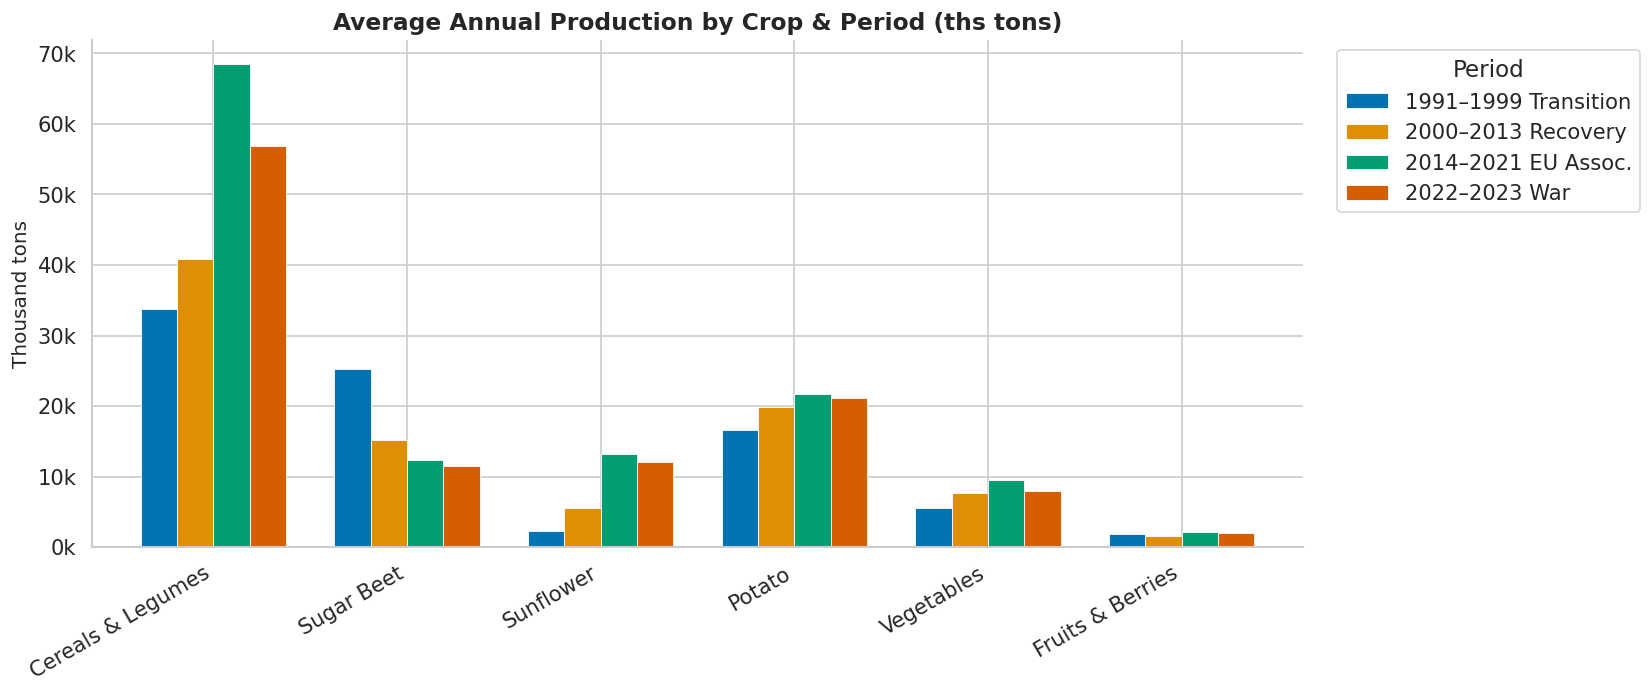

In [15]:
# Grouped Bar: Average Production by Period
prod_period = period_agg[prod_cols].copy()
prod_period.columns = [CROP_NAMES[c] for c in crops]

fig, ax = plt.subplots(figsize=(14,6))
prod_period.T.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)

ax.set_title("Average Annual Production by Crop & Period (ths tons)", fontweight="bold", fontsize=14)
ax.set_ylabel("Thousand tons")
ax.set_xlabel("")
ax.legend(title="Period", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

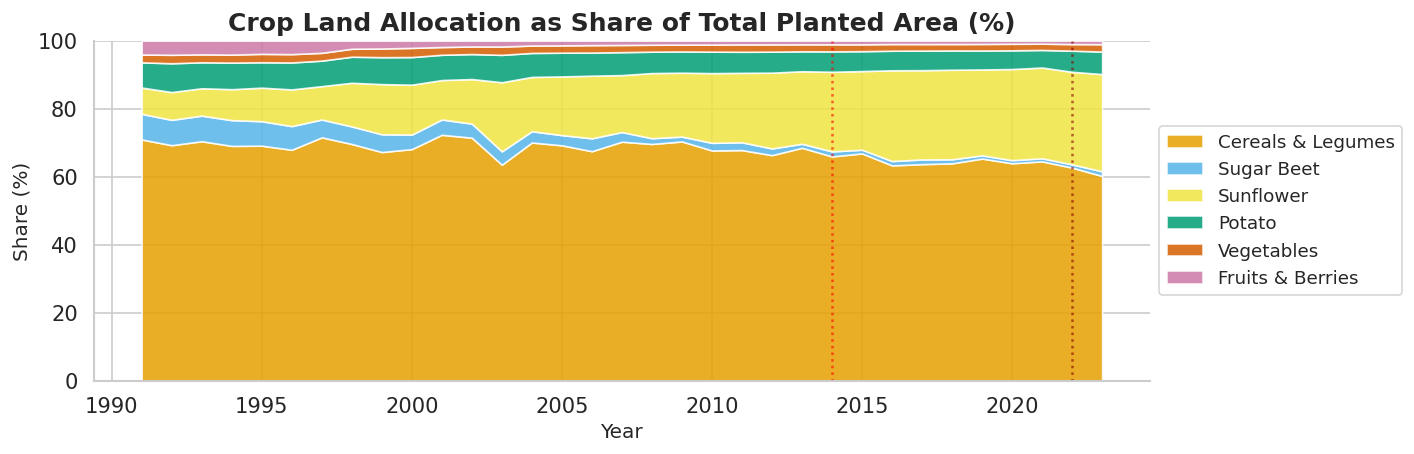

In [16]:
# Land-Use Portfolio Shift
# Stacked Area: Share of Total Planted Area
area_df = df[["year"] + area_cols].copy()
total_area = area_df[area_cols].sum(axis=1)

for col in area_cols:
    crop = col.replace("_ths_ha", "")
    area_df[f"{crop}_pct"] = area_df[col] / total_area * 100


pct_cols = [f"{c}_pct" for c in crops]


fig, ax = plt.subplots(figsize=(12,4))
ax.stackplot(
    area_df["year"],
    *[area_df[col] for col in pct_cols],
    labels =[CROP_NAMES[c] for c in crops],
    colors=[CROP_COLORS[c] for c in crops],
     alpha=0.85,
)

ax.set_title("Crop Land Allocation as Share of Total Planted Area (%)", fontweight="bold", fontsize=15)
ax.set_ylabel("Share (%)")
ax.set_xlabel("Year")
ax.set_ylim(0, 100)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=11)
ax.axvline(2014, color="red", linestyle=":", alpha=0.6)
ax.axvline(2022, color="darkred", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [17]:
# Portfolio Shift: 1991 vs 2023
row_1991 = area_df[area_df["year"] == 1991][pct_cols].values[0]
row_2023 = area_df[area_df["year"] == 2023][pct_cols].values[0]

shift = pd.DataFrame({
    "Crop": [CROP_NAMES[c] for c in crops],
    "1991 share (%)": row_1991.round(1),
    "2023 share (%)": row_2023.round(1),
     "Change (pp)": (row_2023 - row_1991).round(1),
    
})
shift["Direction"] = shift["Change (pp)"].apply(lambda x: "📈 Grew" if x > 0 else "📉 Shrank")
shift.set_index("Crop")

,1991 share (%),2023 share (%),Change (pp),Direction
Crop,,,,
Cereals & Legumes,70.9,60.2,-10.7,📉 Shrank
Sugar Beet,7.5,1.4,-6.2,📉 Shrank
Sunflower,7.7,28.6,20.9,📈 Grew
Potato,7.4,6.6,-0.8,📉 Shrank
Vegetables,2.3,2.2,-0.1,📉 Shrank
Fruits & Berries,4.1,1.0,-3.0,📉 Shrank


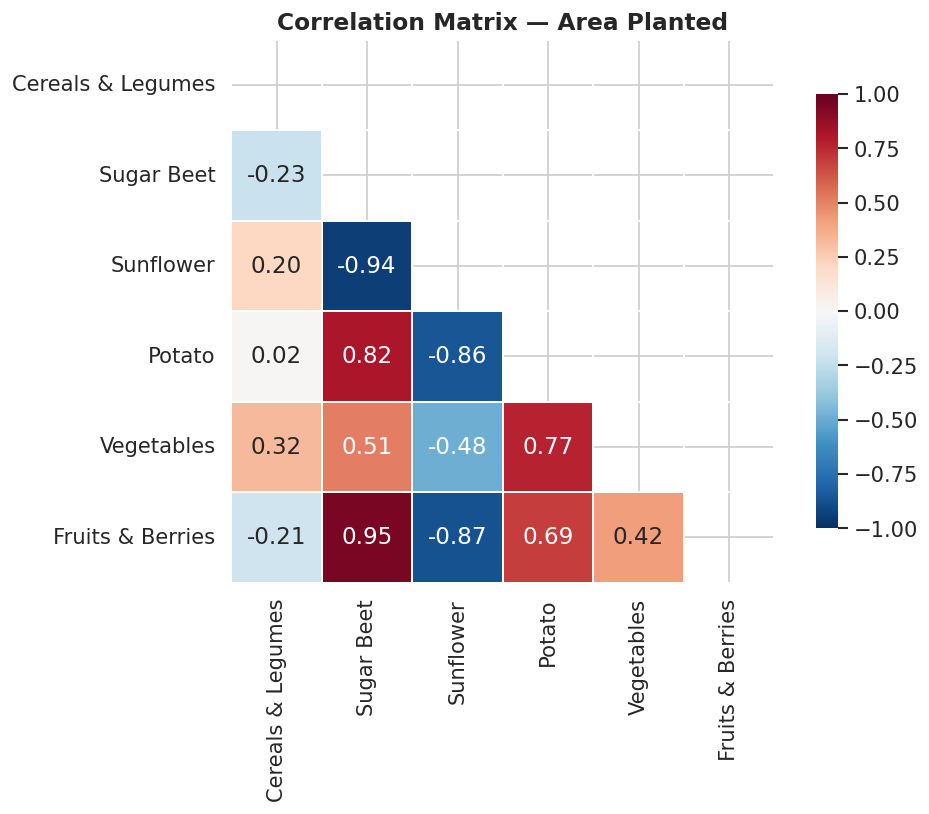

In [18]:
# Correlation & Multivariate Analysis
# Correlation: Area Planted 
corr_area = df[area_cols].corr()
corr_area.columns = [CROP_NAMES[c.replace("_ths_ha", "")] for c in area_cols]
corr_area.index = corr_area.columns

fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr_area, dtype=bool))
sns.heatmap(corr_area, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=1, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Area Planted", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

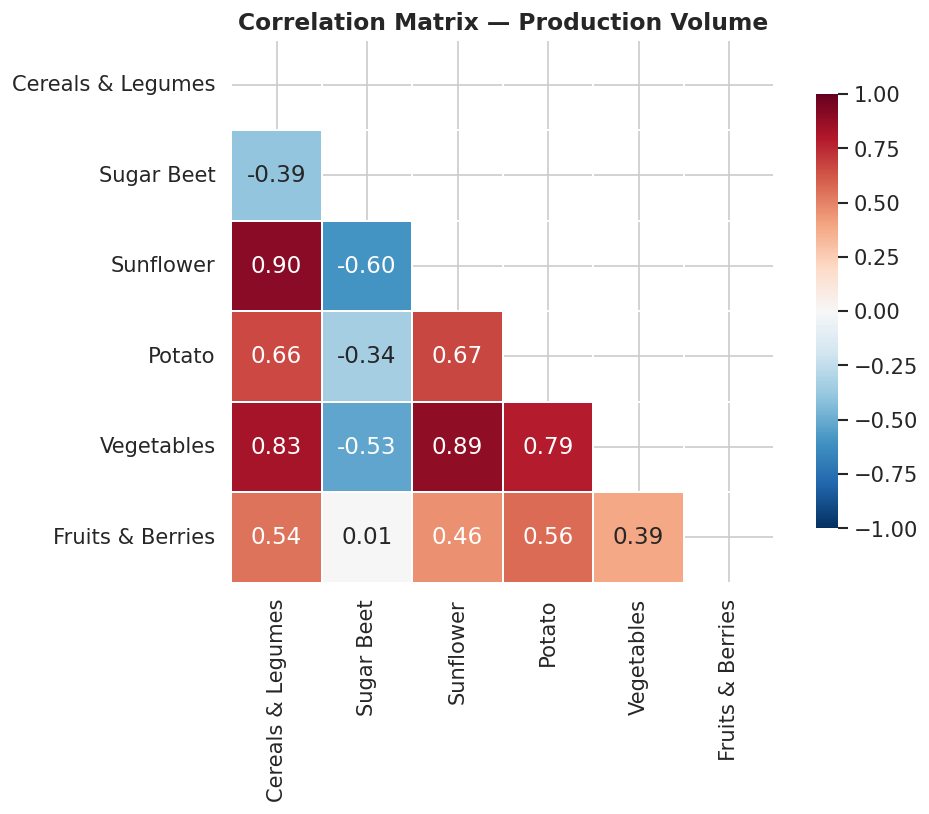

In [19]:
# Correlation: Production
corr_prod = df[prod_cols].corr()
corr_prod.columns = [CROP_NAMES[c.replace("_ths_tons", "")] for c in prod_cols]
corr_prod.index = corr_prod.columns    

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_prod, dtype=bool))
sns.heatmap(corr_prod, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=1, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Production Volume", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

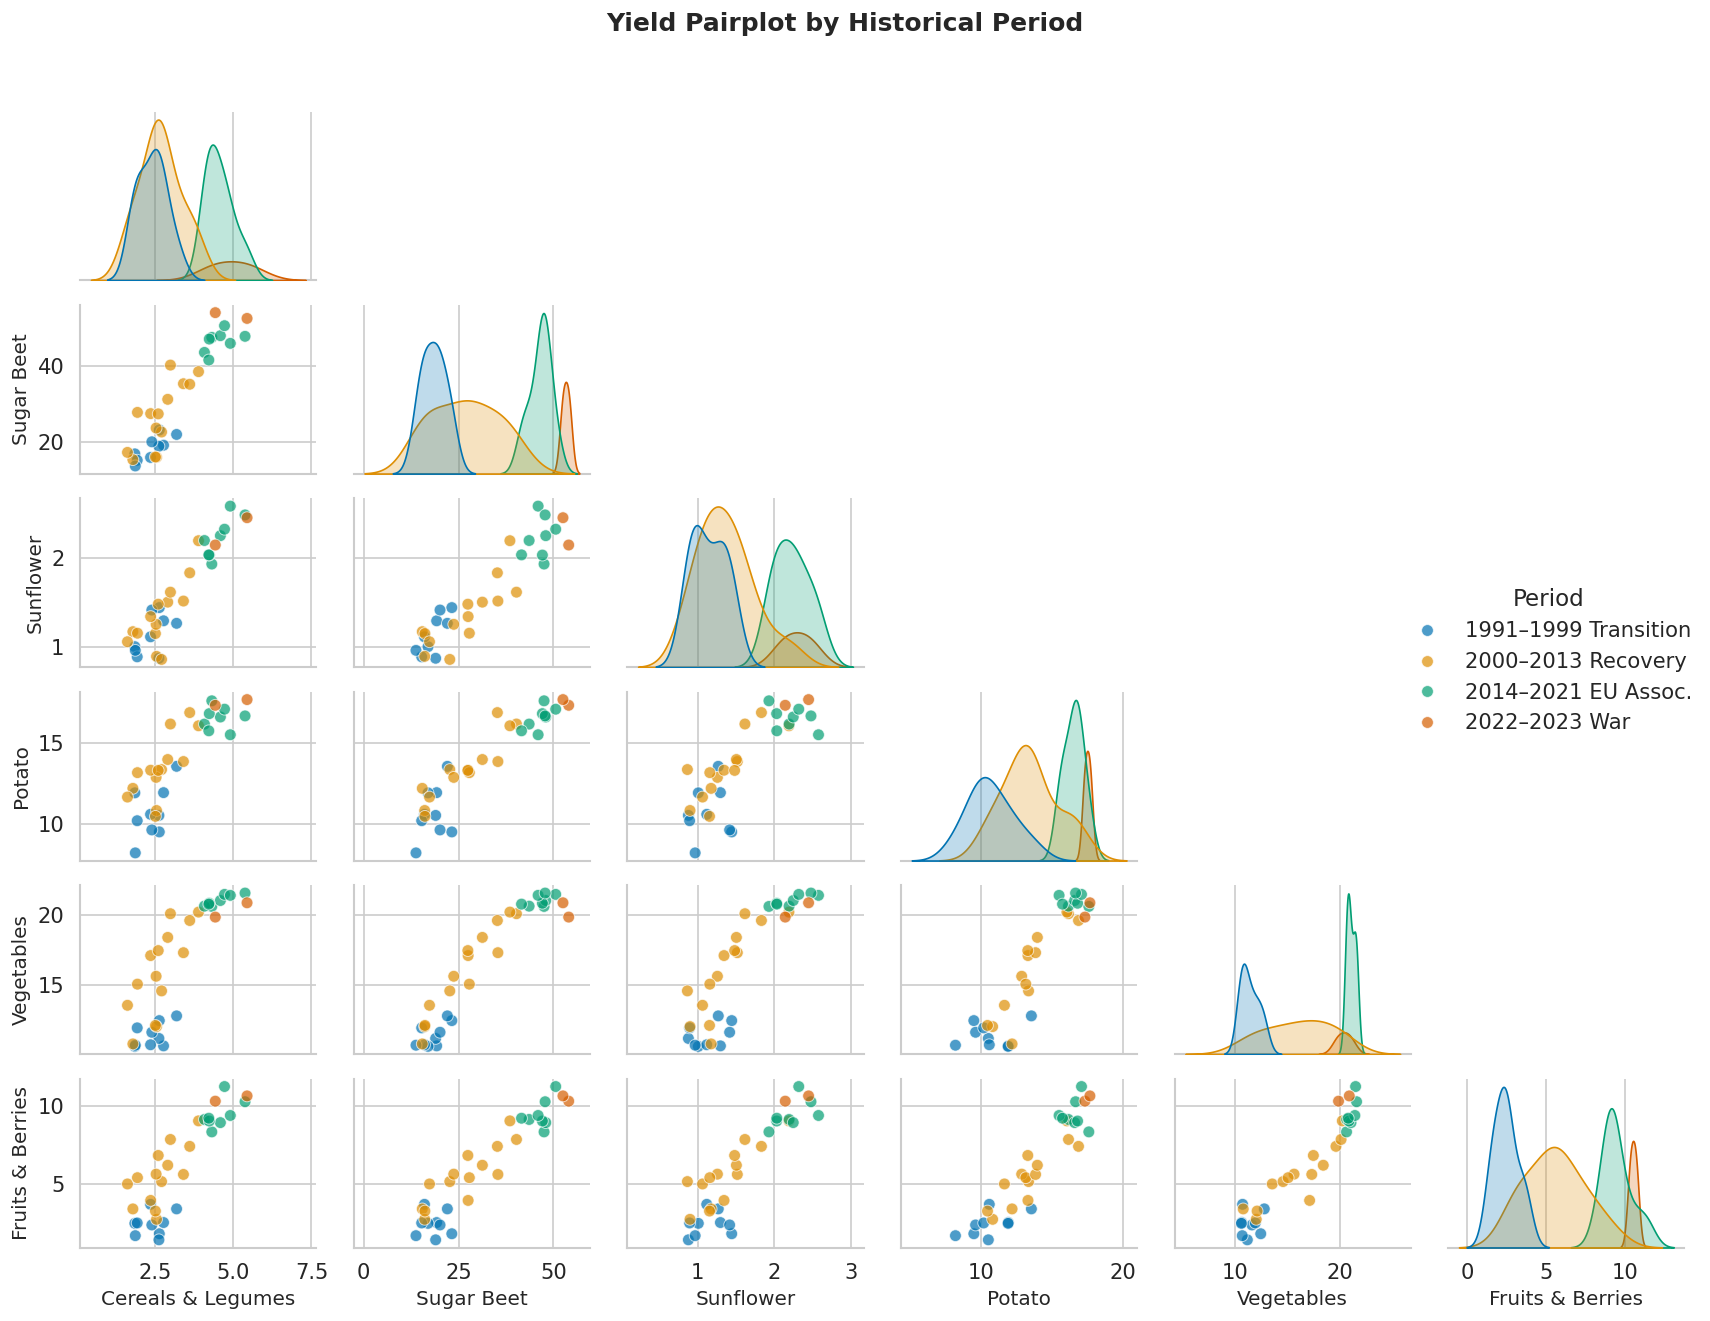

In [20]:
# Pairplot: Yields colored by period
pair_df = df[["period"] + yield_cols].copy()
pair_df.columns = ["Period"] + [CROP_NAMES[c] for c in crops]

g = sns.pairplot(pair_df, hue="Period", hue_order=period_order, diag_kind="kde", corner=True, plot_kws={"alpha": 0.7, "s": 50},  height=1.8, aspect=1.1)
g.figure.suptitle("Yield Pairplot by Historical Period", y=1.02, fontweight="bold", fontsize=15)
plt.tight_layout()
plt.show()

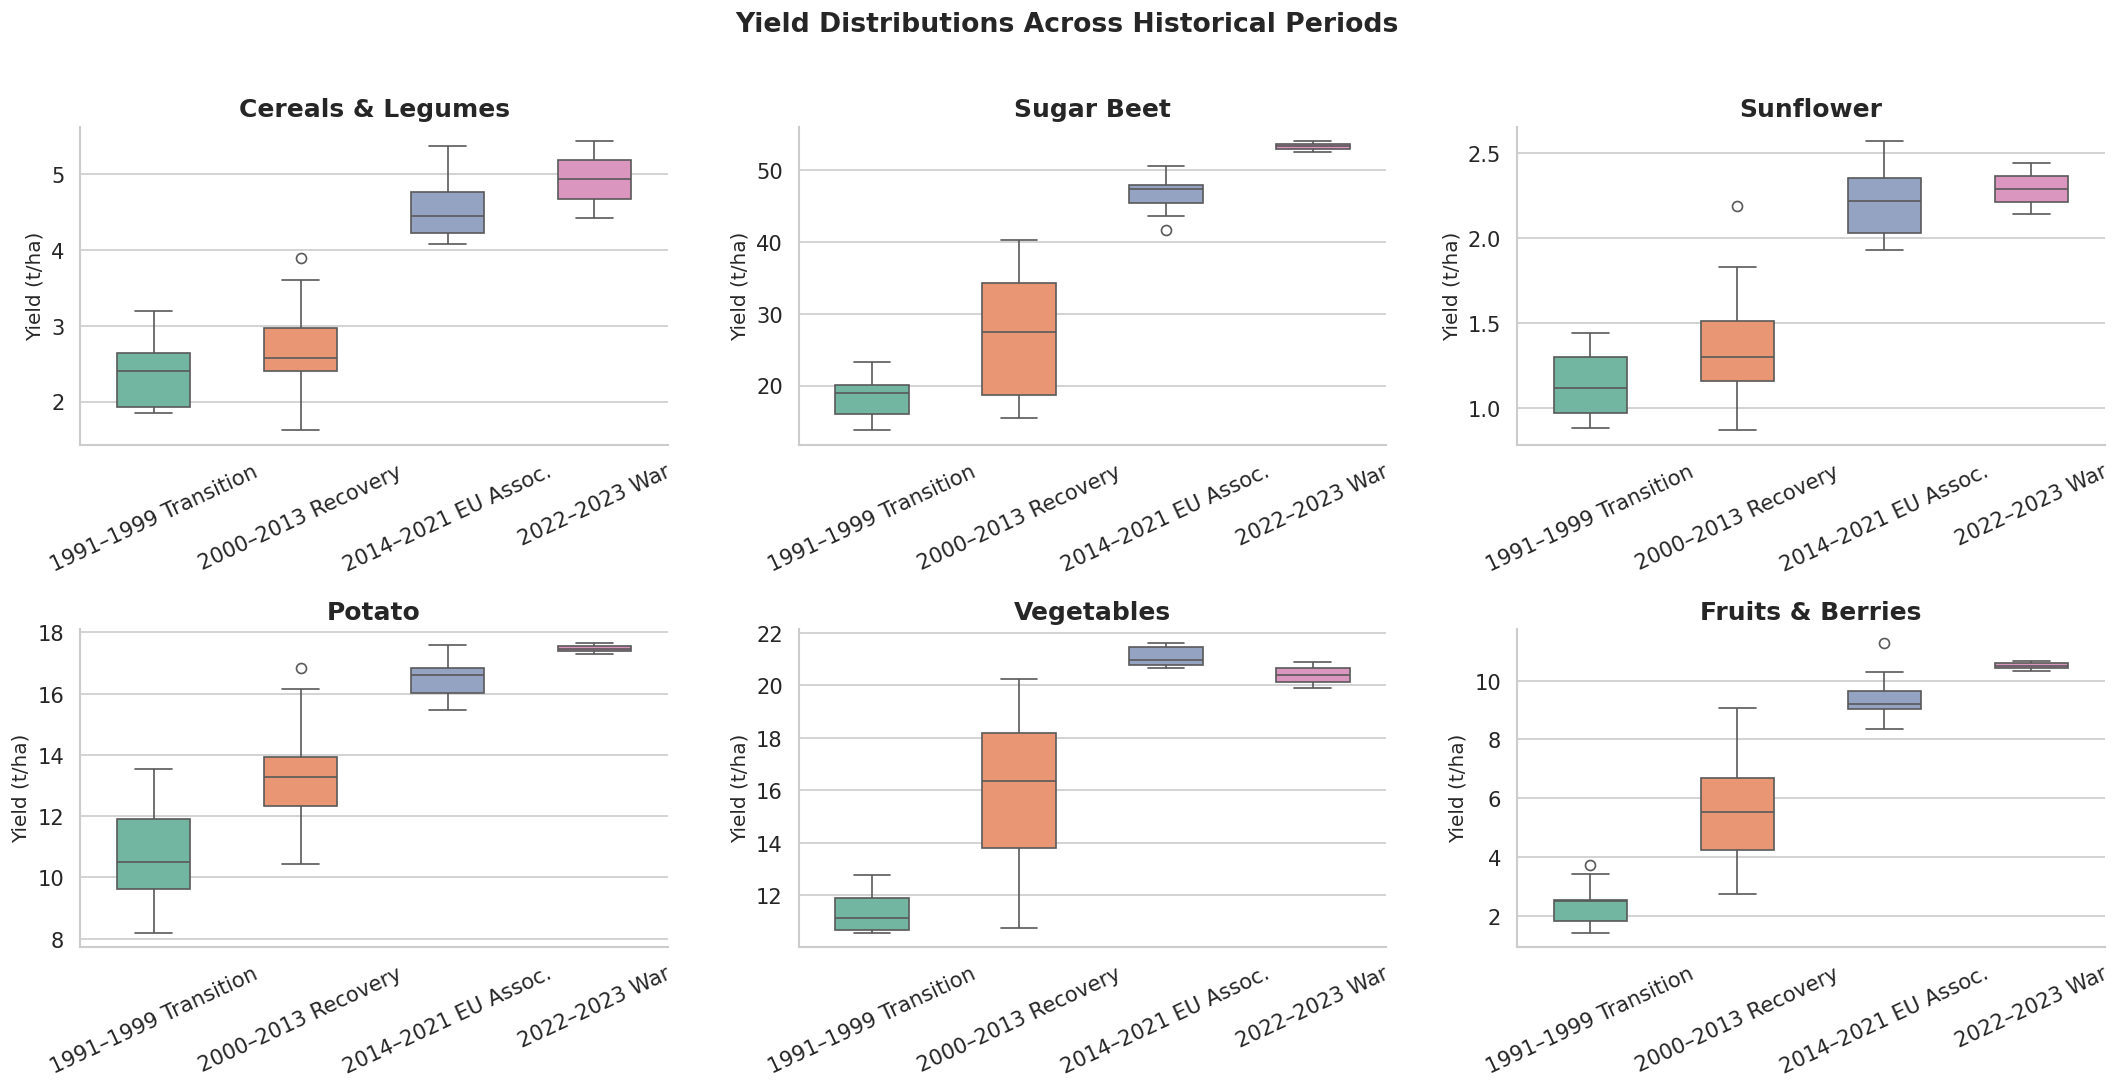

In [21]:
# Distribution & Outlier Analysis
# Box Plots: Yield Distributions by Period 
fig, axes = plt.subplots(2, 3, figsize=(18,9))
axes = axes.flatten()

for i, crop in enumerate (crops):
    ax = axes[i]
    col = f"{crop}_yield_t_ha"
    sns.boxplot(data=df, x="period", y=col, order=period_order, ax=ax, palette="Set2", width=0.5, fliersize=6)
    ax.set_title(CROP_NAMES[crop], fontweight="bold")
    ax.set_ylabel("Yield (t/ha)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Yield Distributions Across Historical Periods", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# Outlier Detection (IQR Method)
print("═" * 60)
print("OUTLIER YEARS (IQR method: < Q1-1.5×IQR or > Q3+1.5×IQR)")
print("═" * 60)

for crop in crops:
    col = f"{crop}_yield_t_ha"
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][["year", col]]
    if len(outliers) > 0:
        print(f"\n {CROP_NAMES[crop]}:")
        for _, row in outliers.iterrows():
            direction = "HIGH" if row[col] > upper else "LOW"
            print(f"   {int(row['year'])} → {row[col]:.2f} t/ha [{direction}]")
    else:
        print(f"\n {CROP_NAMES[crop]}: No outliers detected")

════════════════════════════════════════════════════════════
OUTLIER YEARS (IQR method: < Q1-1.5×IQR or > Q3+1.5×IQR)
════════════════════════════════════════════════════════════

 Cereals & Legumes: No outliers detected

 Sugar Beet: No outliers detected

 Sunflower: No outliers detected

 Potato: No outliers detected

 Vegetables: No outliers detected

 Fruits & Berries: No outliers detected


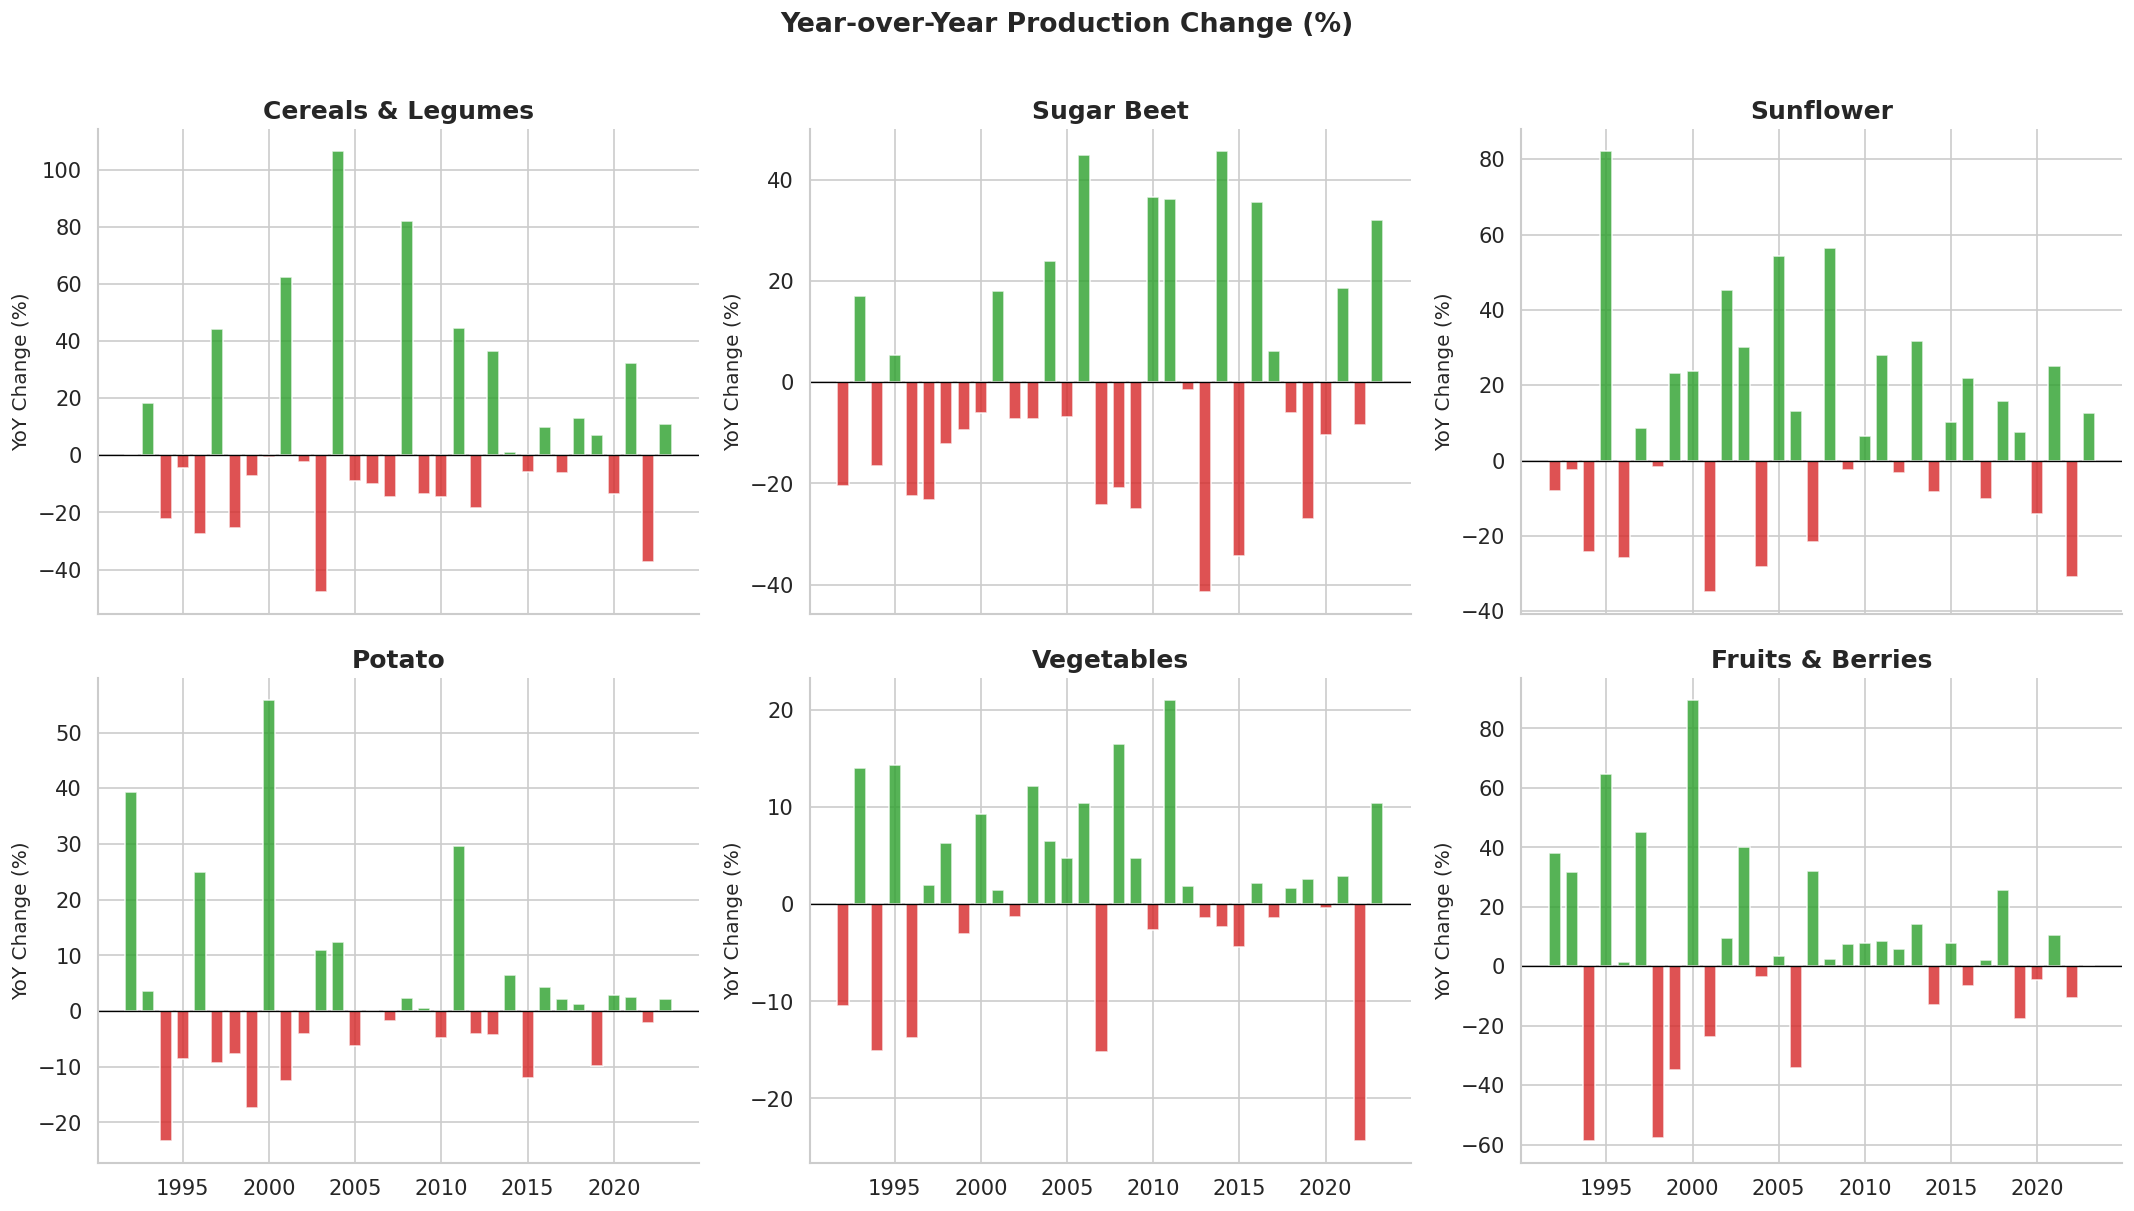

In [23]:
# Year-over-Year Volatility & Growth Rates
# Year-over-Year % Change
yoy_prod = df[prod_cols].pct_change() * 100
yoy_prod["year"] = df["year"]

fig, axes = plt.subplots(2,3, figsize=(18,10), sharex=True)
axes = axes.flatten()

for i, col in enumerate (prod_cols):
    crop = col.replace("_ths_tons", "")
    ax = axes[i]
    vals = yoy_prod[col].dropna()
    years = yoy_prod["year"].iloc[1:]


    colors = ["#d62728" if v < 0 else "#2ca02c" for v in vals]
    ax.bar(years, vals, color=colors, alpha=0.8, width=0.7)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{CROP_NAMES[crop]}", fontweight="bold")
    ax.set_ylabel("YoY Change (%)")

fig.suptitle("Year-over-Year Production Change (%)", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()    

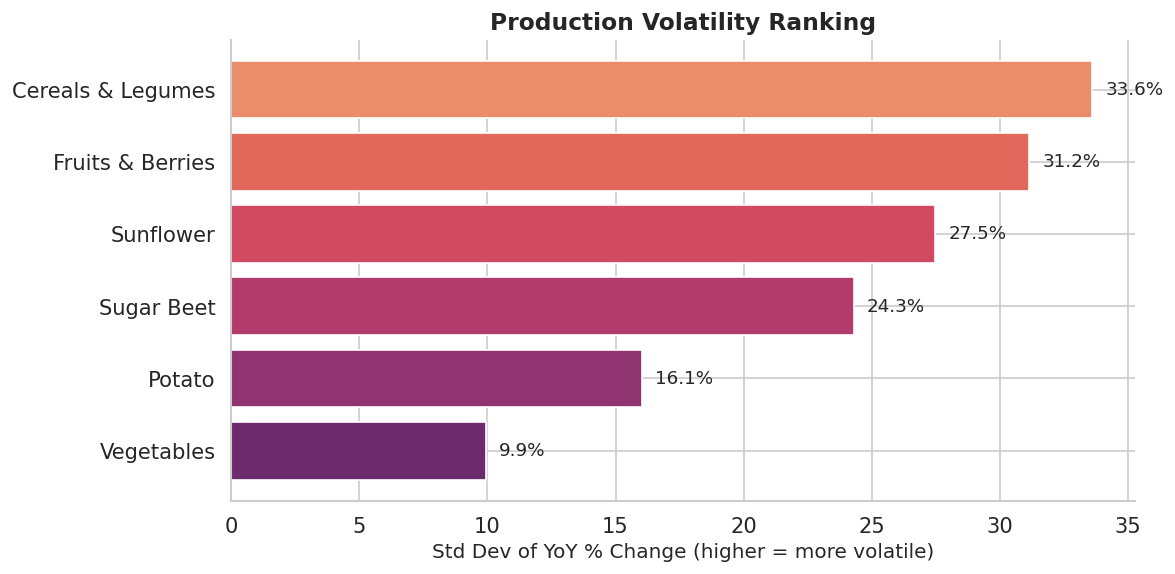

In [24]:
# Volatility Ranking (Std Dev of YoY % changes)
volatility = yoy_prod[prod_cols].std().sort_values(ascending=False)
volatility.index = [CROP_NAMES[c.replace("_ths_tons", "")] for c in volatility.index]

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.barh(volatility.index, volatility.values, color=sns.color_palette("flare", len(volatility)))
ax.set_xlabel("Std Dev of YoY % Change (higher = more volatile)")
ax.set_title("Production Volatility Ranking", fontweight="bold", fontsize=14)
ax.invert_yaxis()
            
for bar, val in zip(bars, volatility.values):
     ax.text(bar.get_width() + 0.5,  bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=11)

plt.tight_layout()
plt.show()    

In [25]:
# Statistical Trend Testing
# Trend Testing: OLS + Spearman rank correlation
print("=" * 75)
print(f"{'Metric':<35} {'Slope/yr':>10} {'r²':>8} {'p-value':>10} {'Sig?':>6}")
print("=" * 75)

all_test_cols = area_cols + prod_cols + yield_cols


for col in all_test_cols:
    x = df["year"].values
    y = df[col].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    sig = "Yes" if p_value < 0.05 else "No"

    # Friendly name
    parts = col.rsplit("_", 2)
    if "yield" in col:
        crop = col.replace("_yield_t_ha", "")
        label = f"{CROP_NAMES[crop]} - Yield"

    elif "ths_ha" in col:
        crop = col.replace("_ths_ha", "")
        label = f"{CROP_NAMES[crop]} — Area"

    else:
        crop = col.replace("_ths_tons", "")
        label =  f"{CROP_NAMES[crop]} — Production"

    print(f"{label:<35} {slope:>+10.1f} {r_value**2:>8.3f} {p_value:>10.4f} {sig:>6}")    
   

Metric                                Slope/yr       r²    p-value   Sig?
Cereals & Legumes — Area                 +11.9    0.009     0.5903     No
Sugar Beet — Area                        -45.4    0.907     0.0000    Yes
Sunflower — Area                        +158.5    0.932     0.0000    Yes
Potato — Area                            -12.0    0.832     0.0000    Yes
Vegetables — Area                         -1.9    0.381     0.0001    Yes
Fruits & Berries — Area                  -20.5    0.766     0.0000    Yes
Cereals & Legumes — Production         +1351.0    0.620     0.0000    Yes
Sugar Beet — Production                 -541.5    0.556     0.0000    Yes
Sunflower — Production                  +455.9    0.878     0.0000    Yes
Potato — Production                     +194.0    0.457     0.0000    Yes
Vegetables — Production                 +158.9    0.751     0.0000    Yes
Fruits & Berries — Production            +15.4    0.097     0.0779     No
Cereals & Legumes - Yield             

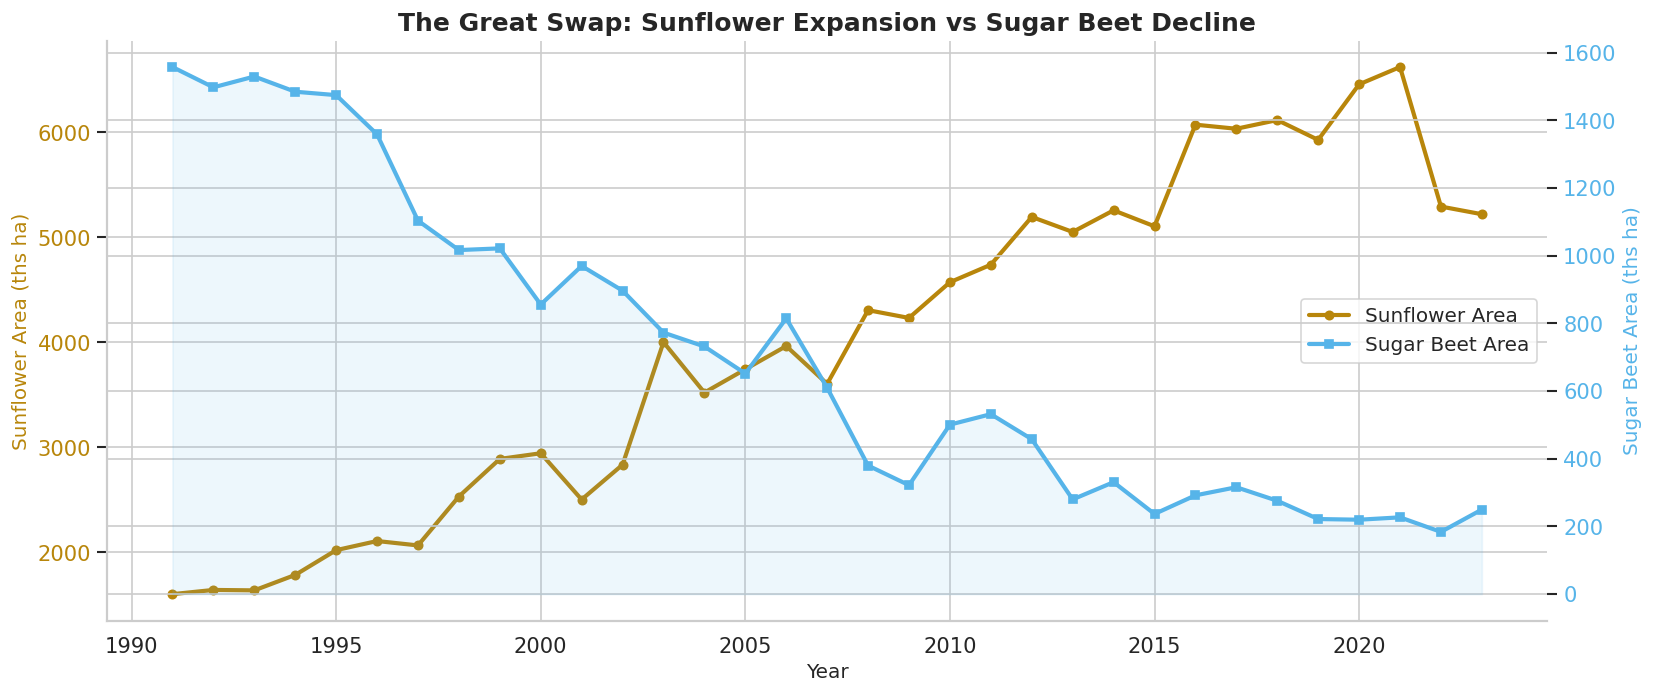

Pearson correlation (Sunflower area ↔ Sugar Beet area): r = -0.940, p = 4.53e-16


In [26]:
# Deep Dive: Sunflower Boom vs. Sugar Beet Collapse
fig, ax1 = plt.subplots(figsize=(14,6))

color_sun = CROP_COLORS["sunflower"]
color_beet = CROP_COLORS["sugar_beet"]

ax1.set_xlabel("Year")
ax1.set_ylabel("Sunflower Area (ths ha)", color="#B8860B")
l1 = ax1.plot(df["year"], df["sunflower_ths_ha"], color="#B8860B", linewidth=2.5, marker="o", markersize=5, label="Sunflower Area")
ax1.tick_params(axis="y", labelcolor="#B8860B")

ax2 = ax1.twinx()
ax2.set_ylabel("Sugar Beet Area (ths ha)", color=color_beet)
l2 = ax2.plot(df["year"], df["sugar_beet_ths_ha"], color=color_beet, linewidth=2.5, marker="s", markersize=5, label="Sugar Beet Area")
ax2.fill_between(df["year"], df["sugar_beet_ths_ha"], alpha=0.1, color=color_beet)
ax2.tick_params(axis="y", labelcolor=color_beet)

# Combine legends
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right", fontsize=12)

ax1.set_title("The Great Swap: Sunflower Expansion vs Sugar Beet Decline",
              fontweight="bold", fontsize=15)
fig.tight_layout()
plt.show()

# Correlation
r, p = stats.pearsonr(df["sunflower_ths_ha"], df["sugar_beet_ths_ha"])
print(f"Pearson correlation (Sunflower area ↔ Sugar Beet area): r = {r:.3f}, p = {p:.2e}")

══════════════════════════════════════════════════════════════════════
WAR IMPACT: 2022–2023 vs 2019–2021 Baseline
══════════════════════════════════════════════════════════════════════


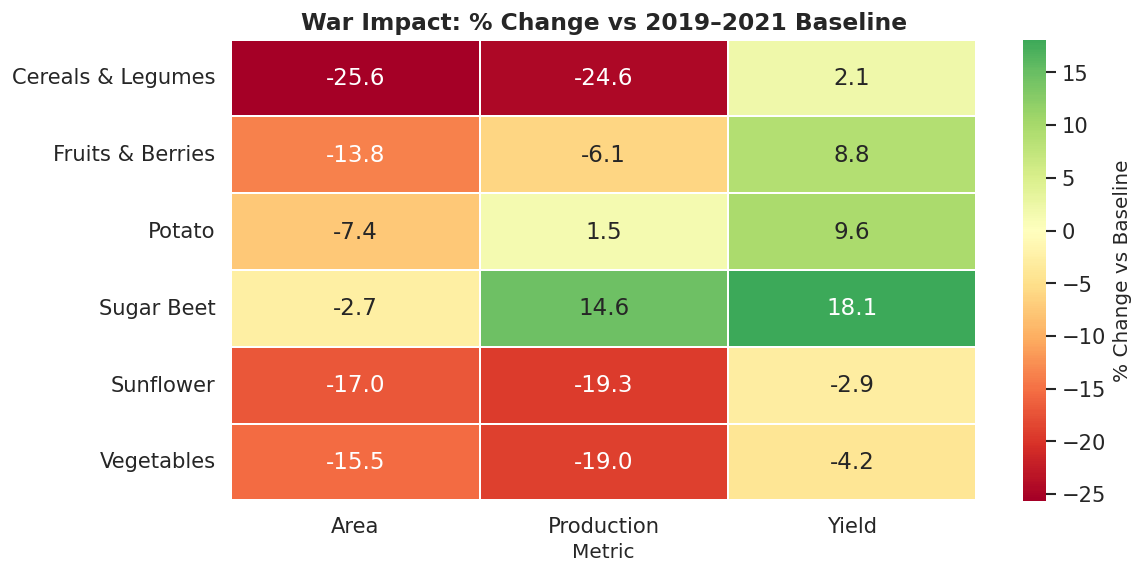

In [32]:
# War Impact Analysis (2022–2023)
# War Impact: 2022–2023 vs 2019–2021 baseline
baseline = df[df["year"].between(2019, 2021)]
war = df[df["year"].between(2022, 2023)]

print("═" * 70)
print("WAR IMPACT: 2022–2023 vs 2019–2021 Baseline")
print("═" * 70)

impact_data = []
for crop in crops:
    for suffix, label in [("_ths_ha", "Area"), ("_ths_tons", "Production"), ("_yield_t_ha", "Yield")]:
        col = f"{crop}{suffix}"
        if col in df.columns:
            base_avg = baseline[col].mean()
            war_avg = war[col].mean()
            change_pct = (war_avg - base_avg) / base_avg * 100
            impact_data.append({
                "Crop": CROP_NAMES[crop],
                "Metric": label,
                "Baseline (2019–21)": round(base_avg, 1),
                "War (2022–23)": round(war_avg, 1),
                "Change %": round(change_pct, 1),
            })
impact_df = pd.DataFrame(impact_data)
pivot = impact_df.pivot_table(index="Crop", columns="Metric", values="Change %")
pivot = pivot[["Area", "Production", "Yield"]]

# Styled heatmap
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, linewidths=1, linecolor="white", ax=ax, cbar_kws={"label": "% Change vs Baseline"})
ax.set_title("War Impact: % Change vs 2019–2021 Baseline", fontweight="bold", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

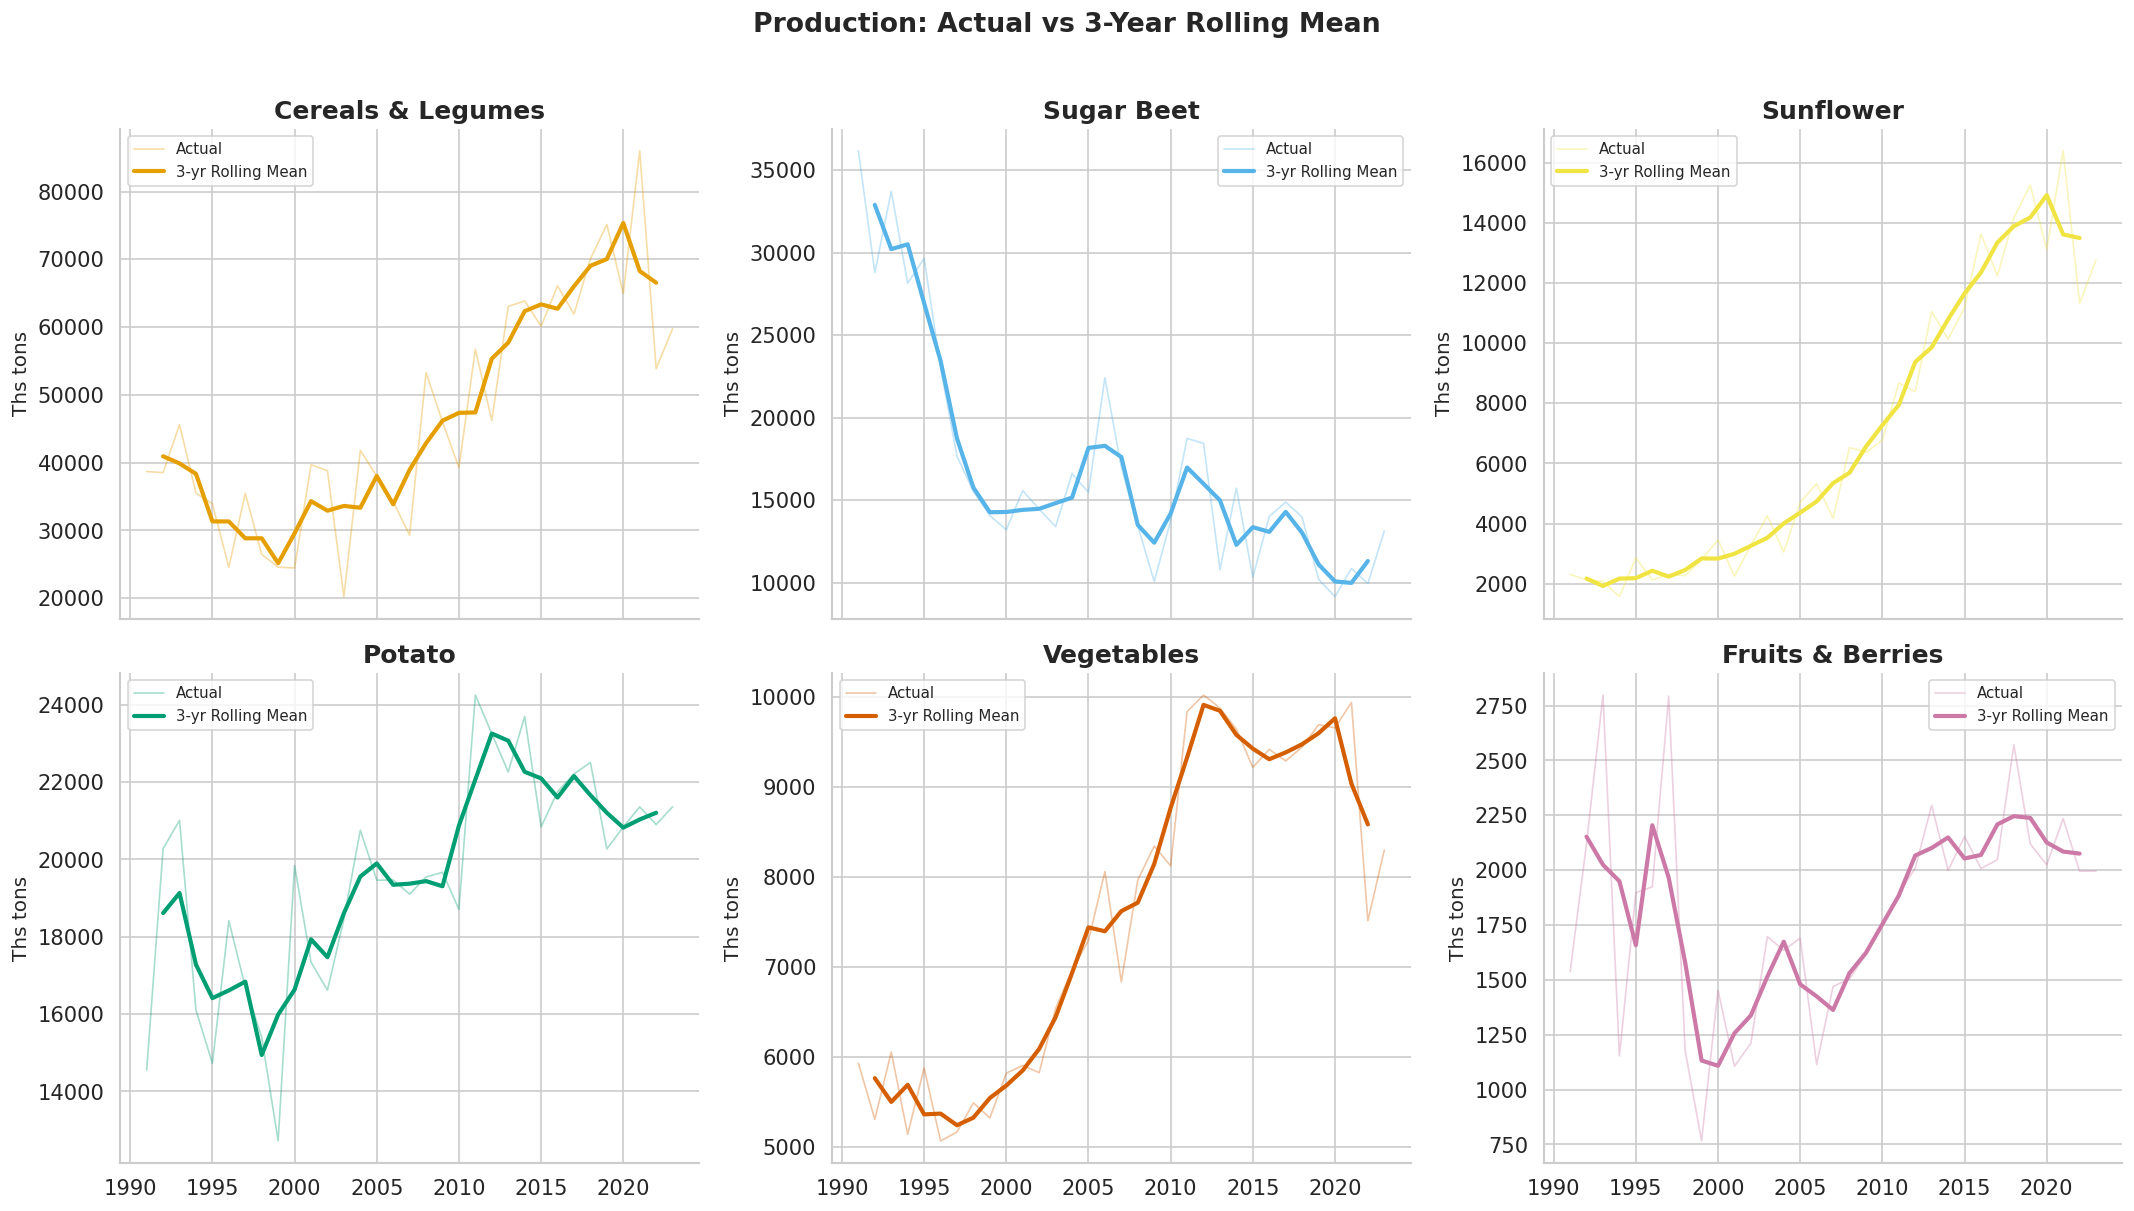

In [28]:
# Rolling Averages & Smoothed Trends
# 3-Year Rolling Mean: Production
fig, axes = plt.subplots(2,3, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(prod_cols):
    crop = col.replace("_ths_tons", "")
    ax = axes[i]

    ax.plot(df["year"], df[col], color=CROP_COLORS[crop], alpha=0.35, linewidth=1, label="Actual")
    rolling = df[col].rolling(3, center=True).mean()
    ax.plot(df["year"], rolling, color=CROP_COLORS[crop], linewidth=2.5, label="3-yr Rolling Mean")
    ax.set_title(CROP_NAMES[crop], fontweight="bold")
    ax.set_ylabel("Ths tons")
    ax.legend(fontsize=9)
    
fig.suptitle("Production: Actual vs 3-Year Rolling Mean", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()    

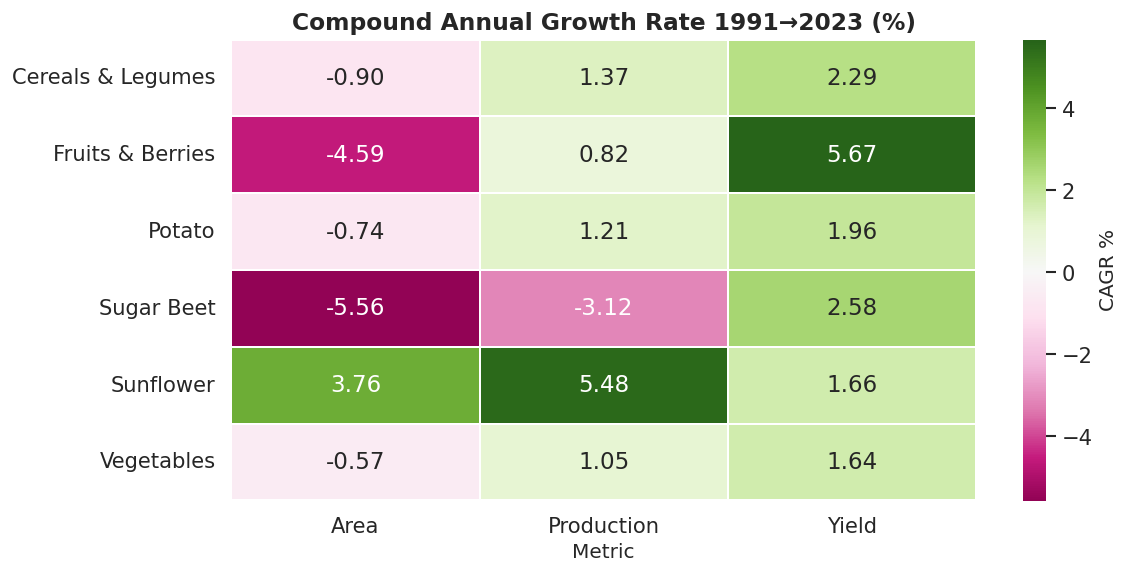


  Interpretation: Positive = growth, Negative = decline


In [29]:
# Compound Annual Growth Rate (CAGR)
# CAGR Calculation
def cagr(start, end, years):
    if start <= 0 or end <= 0:
        return np.nan
    return ((end / start) ** (1 / years) - 1) * 100

n_years = df["year"].max() - df["year"].min()

cagr_data = []
for crop in crops:
    for suffix, metric in[("_ths_ha", "Area"), ("_ths_tons", "Production"), ("_yield_t_ha", "Yield")]:
        col = f"{crop}{suffix}"
        if col in df.columns:
            val = cagr(df[col].iloc[0], df[col].iloc[-1], n_years)
            cagr_data.append({"Crop": CROP_NAMES[crop], "Metric": metric, "CAGR %": round(val, 2)})
        
cagr_df = pd.DataFrame(cagr_data).pivot(index="Crop", columns="Metric", values="CAGR %")
cagr_df = cagr_df[["Area", "Production", "Yield"]]


fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cagr_df, annot=True, fmt=".2f", cmap="PiYG", center=0, 
            linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"label": "CAGR %"})
ax.set_title("Compound Annual Growth Rate 1991→2023 (%)", fontweight="bold", fontsize=14)
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("\n  Interpretation: Positive = growth, Negative = decline")


In [30]:
# Record Years Dashboard
records = []
for crop in crops:
    col_prod = f"{crop}_ths_tons"
    col_yield = f"{crop}_yield_t_ha"

    best_prod_idx = df[col_prod].idxmax()
    worst_prod_idx = df[col_prod].idxmin()
    best_yield_idx = df[col_yield].idxmax()

    records.append({
        "Crop": CROP_NAMES[crop],
        "Best Production Year": int(df.loc[best_prod_idx, "year"]),
        "Best Production (ths t)": f"{df.loc[best_prod_idx, col_prod]:,.0f}",
        "Worst Production Year": int(df.loc[worst_prod_idx, "year"]),
        "Worst Production (ths t)": f"{df.loc[worst_prod_idx, col_prod]:,.0f}",
        "Best Yield Year": int(df.loc[best_yield_idx, "year"]),
        "Best Yield (t/ha)": f"{df.loc[best_yield_idx, col_yield]:.2f}",
    })
records_df = pd.DataFrame(records).set_index("Crop")
records_df

,Best Production Year,Best Production (ths t),Worst Production Year,Worst Production (ths t),Best Yield Year,Best Yield (t/ha)
Crop,,,,,,
Cereals & Legumes,2021,"86,010",2003,"20,234",2023,5.44
Sugar Beet,1991,"36,168",2020,"9,150",2022,54.03
Sunflower,2021,"16,392",1994,"1,569",2019,2.57
Potato,2011,"24,248",1999,"12,723",2023,17.65
Vegetables,2012,"10,017",1996,"5,070",2021,21.60
Fruits & Berries,1993,"2,798",1999,766,2018,11.28


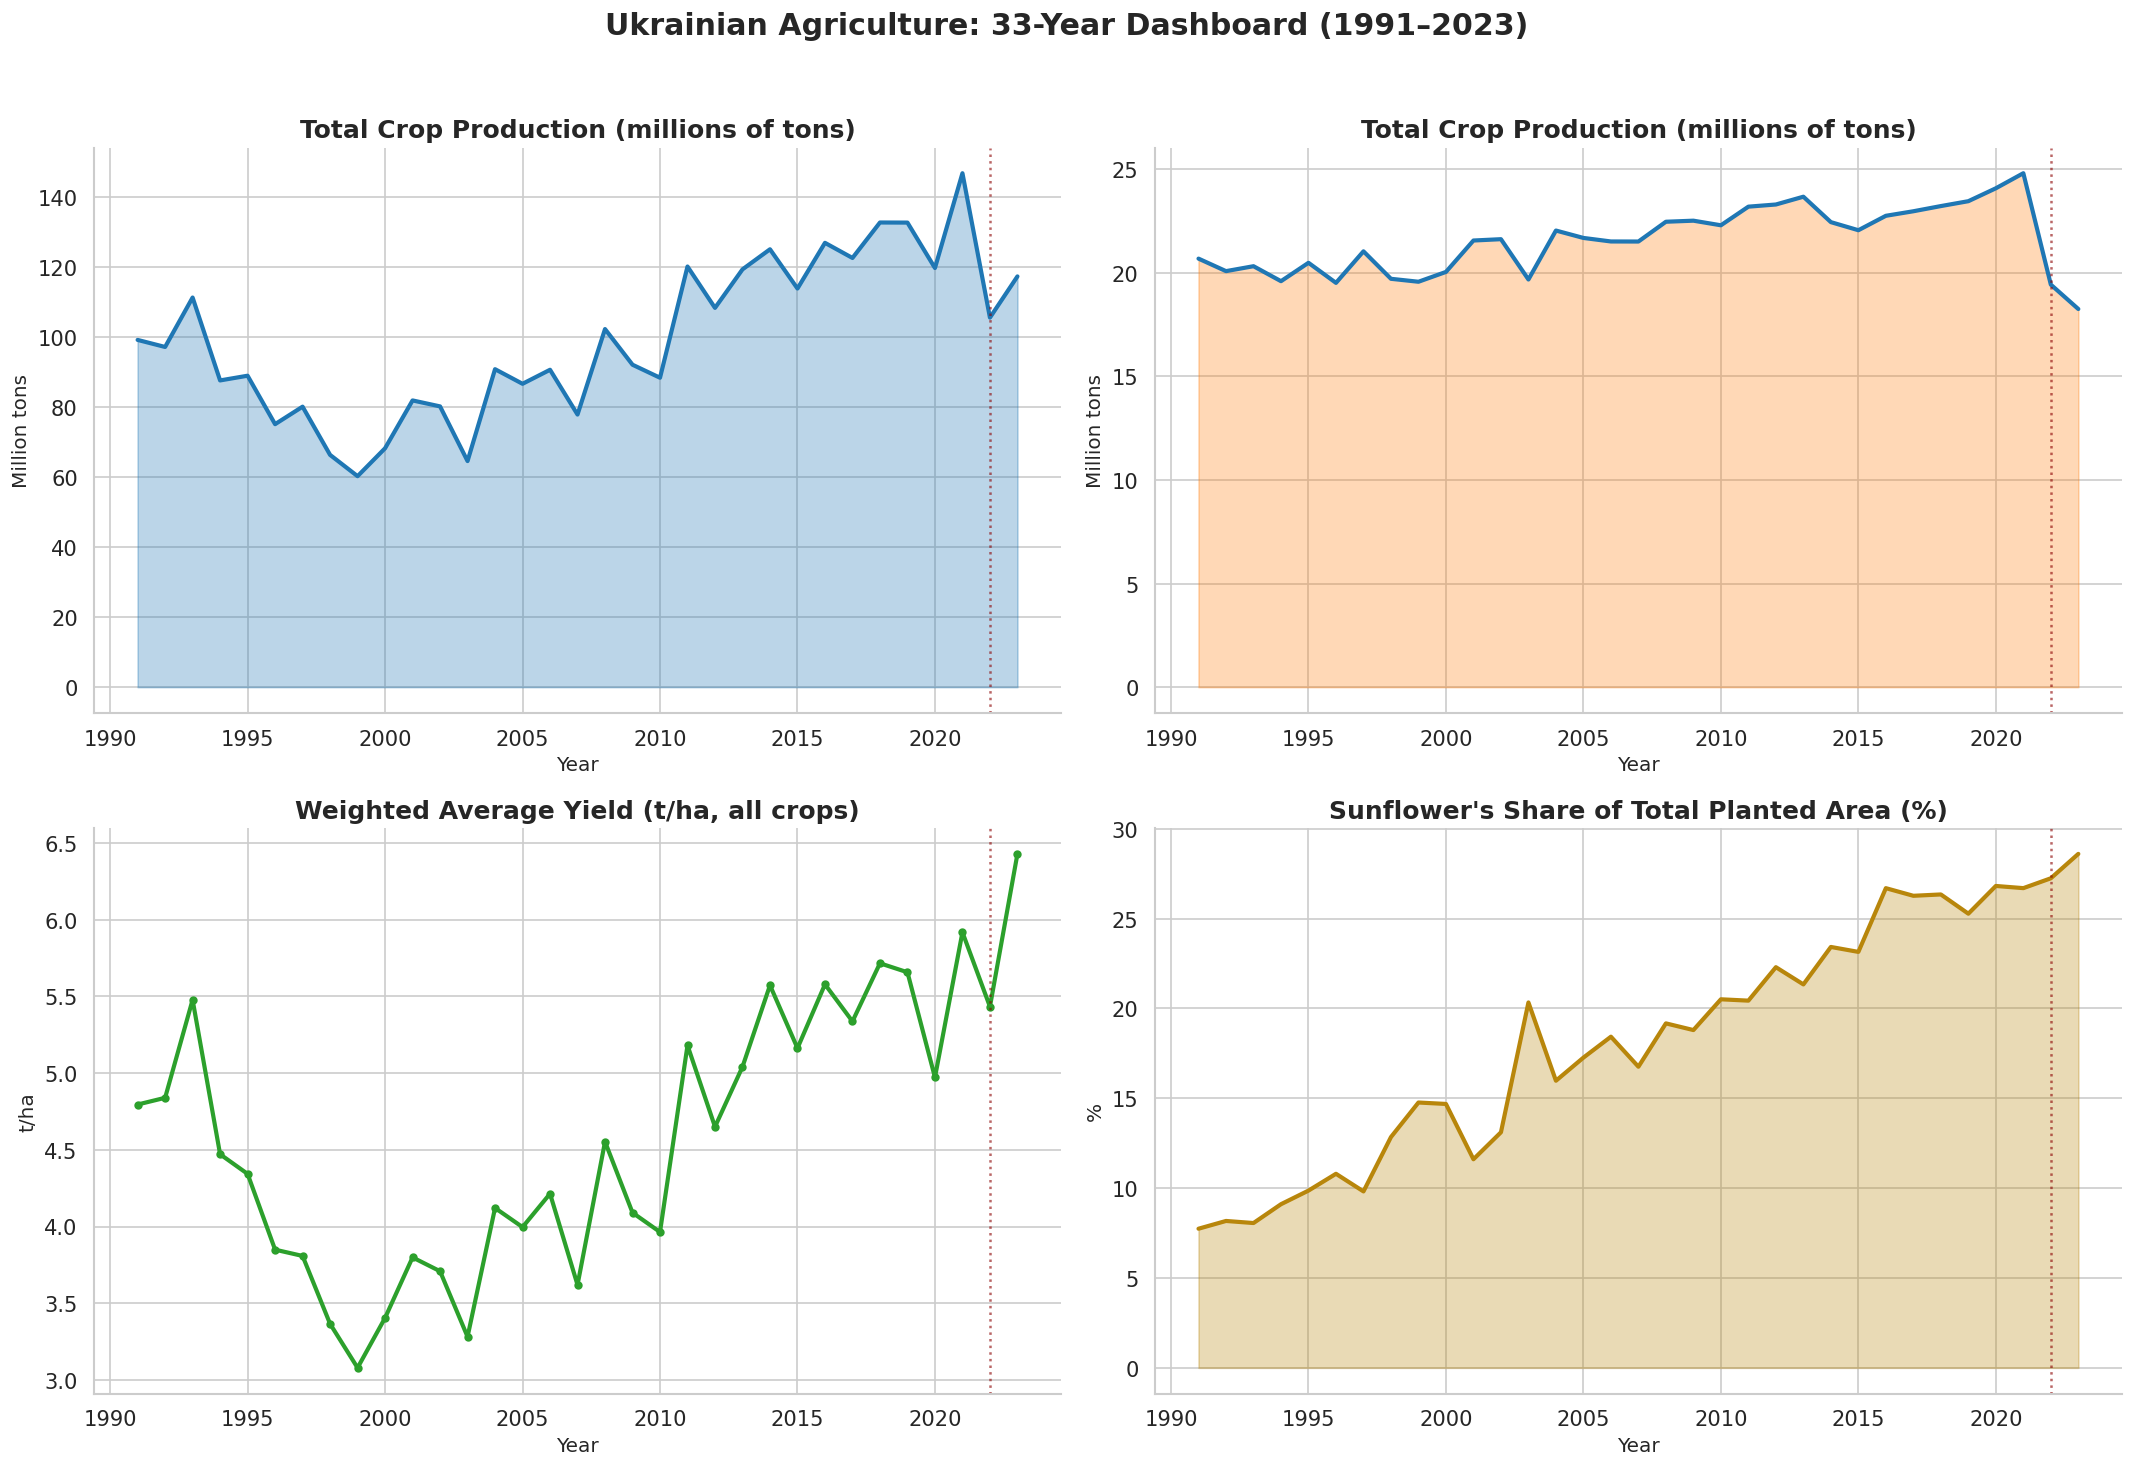

In [31]:
# Summary Dashboard, All Key Metrics at a Glance
fig, axes = plt.subplots(2,2, figsize=(18, 12))

# Total agricultural production
total_prod = df[prod_cols].sum(axis=1)
ax = axes[0, 0]
ax.fill_between(df["year"], total_prod / 1000, alpha=0.3, color="#1f77b4")
ax.plot(df["year"], total_prod / 1000, color="#1f77b4", linewidth=2.5)
ax.set_title("Total Crop Production (millions of tons)", fontweight="bold")
ax.set_ylabel("Million tons")
ax.axvline(2022, color="darkred", linestyle=":", alpha=0.6)

# Total planted area
total_area = df[area_cols].sum(axis=1)
ax = axes[0, 1]
ax.fill_between(df["year"], total_area / 1000, alpha=0.3, color="#ff7f0e")
ax.plot(df["year"], total_area / 1000, color="#1f77b4", linewidth=2.5)
ax.set_title("Total Crop Production (millions of tons)", fontweight="bold")
ax.set_ylabel("Million tons")
ax.axvline(2022,  color="darkred", linestyle=":", alpha=0.6)

# Weighted average yield
ax = axes[1, 0]
weighted_yield = total_prod / total_area
ax.plot(df["year"], weighted_yield, color="#2ca02c", linewidth=2.5, marker="o", markersize=4)
ax.set_title("Weighted Average Yield (t/ha, all crops)", fontweight="bold")
ax.set_ylabel("t/ha")
ax.axvline(2022, color="darkred", linestyle=":", alpha=0.6)

# Sunflower share of area
ax = axes[1, 1]
sun_share = df["sunflower_ths_ha"] / total_area * 100
ax.fill_between(df["year"], sun_share, alpha=0.3, color="#B8860B")
ax.plot(df["year"], sun_share, color="#B8860B", linewidth=2.5)
ax.set_title("Sunflower's Share of Total Planted Area (%)", fontweight="bold")
ax.set_ylabel("%")
ax.axvline(2022, color="darkred", linestyle=":", alpha=0.6)

for a in axes.flatten():
    a.set_xlabel("Year")

fig.suptitle("Ukrainian Agriculture: 33-Year Dashboard (1991–2023)",
             fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
"""

"""